In [30]:
import pandas as pd
from huggingface_hub import hf_hub_download
import numpy as np
from sklearn.metrics.pairwise import cosine_distances
import matplotlib.pyplot as plt
import seaborn as sns


In [31]:
#1. Loading data 

file_path_metadata = hf_hub_download(
    "recursionpharma/rxrx3-core",
    filename="metadata_rxrx3_core.csv",
    repo_type="dataset"
)

In [32]:
metadata_df = pd.read_csv(file_path_metadata)
print(metadata_df.head())

                well_id experiment_name  plate address gene       treatment  \
0  compound-003_11_AD37    compound-003     11    AD37  NaN       Phloretin   
1   compound-003_35_Y15    compound-003     35     Y15  NaN       Clozapine   
2   compound-001_19_D20    compound-001     19     D20  NaN     Dequalinium   
3   compound-001_11_U08    compound-001     11     U08  NaN   EMPTY_control   
4   compound-004_43_B08    compound-004     43     B08  NaN  CRISPR_control   

                                              SMILES  concentration  \
0  OC1=CC=C(CCC(=O)C2=C(O)C=C(O)C=C2O)C=C1 |c:9,1...          0.025   
1  CN1CCN(CC1)C1=NC2=C(NC3=C1C=CC=C3)C=CC(Cl)=C2 ...          2.500   
2  CC1=[N+](CCCCCCCCCC[N+]2=C(C)C=C(N)C3=CC=CC=C2...          0.250   
3                                                NaN            NaN   
4                                                NaN            NaN   

  perturbation_type cell_type  
0          COMPOUND     HUVEC  
1          COMPOUND     HUVEC  
2 

/var/folders/pp/nppvp0b553397d5c5glkf28c0000gn/T/ipykernel_26895/3397217607.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata_df = pd.read_csv(file_path_metadata)


In [33]:
metadata_df.columns

Index(['well_id', 'experiment_name', 'plate', 'address', 'gene', 'treatment',
       'SMILES', 'concentration', 'perturbation_type', 'cell_type'],
      dtype='object')

In [34]:
for col in metadata_df.columns:
    n_unique = metadata_df[col].nunique()
    print(f"\n --- {col} ({n_unique} unique values) ---")
    if n_unique <= 20:
        print(metadata_df[col].value_counts())
    else:
        print(metadata_df[col].dtype, "| sample:", metadata_df[col].dropna().iloc[:3].tolist())


 --- well_id (222601 unique values) ---
object | sample: ['compound-003_11_AD37', 'compound-003_35_Y15', 'compound-001_19_D20']

 --- experiment_name (180 unique values) ---
object | sample: ['compound-003', 'compound-003', 'compound-001']

 --- plate (48 unique values) ---
int64 | sample: [11, 35, 19]

 --- address (1380 unique values) ---
object | sample: ['AD37', 'Y15', 'D20']

 --- gene (736 unique values) ---
object | sample: ['AP2S1', 'IMPDH1', 'RPLP2']

 --- treatment (6108 unique values) ---
object | sample: ['Phloretin', 'Clozapine', 'Dequalinium']

 --- SMILES (1674 unique values) ---
object | sample: ['OC1=CC=C(CCC(=O)C2=C(O)C=C(O)C=C2O)C=C1 |c:9,15,19,t:1,3,12|', 'CN1CCN(CC1)C1=NC2=C(NC3=C1C=CC=C3)C=CC(Cl)=C2 |c:10,13,16,18,21,24,t:8|', 'CC1=[N+](CCCCCCCCCC[N+]2=C(C)C=C(N)C3=CC=CC=C23)C2=CC=CC=C2C(N)=C1 |c:1,13,21,29,31,35,t:16,19,23,27|']

 --- concentration (12 unique values) ---
concentration
0.2500     11527
2.5000     11508
1.0000      6734
0.0100      6733
0.0025    

In [7]:
print(metadata_df[metadata_df['perturbation_type'] == 'COMPOUND']['treatment'].value_counts().head(20))
print(metadata_df[metadata_df['perturbation_type'] == 'COMPOUND']['treatment'].value_counts().sum())


treatment
CRISPR_control             22062
EMPTY_control              10234
Flavopiridol                 352
BI 2536                      352
BIIB021                      352
BIRB 796                     352
MI-773                       352
KPT-185                      352
Amfebutamone                 352
PD0325901                    352
GDC-0994                     352
PD168393                     352
lovastatin                   352
Thiazovivin                  352
Rufinamide                   352
LY2835219                    352
6-Mercaptopurine (6-MP)      352
CEP-18770                    352
Trazodone                    352
Esomeprazole                 351
Name: count, dtype: int64
95701


In [35]:
print(metadata_df[metadata_df['perturbation_type'] == 'CRISPR']['gene'].value_counts().head(20))
print(metadata_df[metadata_df['perturbation_type'] == 'CRISPR']['gene'].value_counts().sum())


gene
EMPTY_control    25312
PLK1              9471
MTOR              9456
SRC               1672
EIF3H             1669
HCK               1667
CYP11B1           1559
RPL10              216
RPL23A             216
AKR1B1             216
ACTG1              216
MAOA               216
ATP5F1C            216
CTNNA1             216
SEC11A             215
GABRA1             215
ACTB               215
DLST               212
PGD                212
MAP2K2             209
Name: count, dtype: int64
126900


In [36]:
metadata_df['plate'].value_counts()
metadata_df['plate'].value_counts().sum()

np.int64(222601)

In [37]:
metadata_df.iloc[:,6].value_counts(dropna = False).head()

SMILES
NaN                                                                                                     159196
[H][C@@]1(CCN(C)C[C@H]1O)C1=C2OC(=CC(=O)C2=C(O)C=C1O)C1=C(Cl)C=CC=C1 |c:10,13,21,25,28,30,t:18|            352
[H][C@]12[C@H](C[C@@H](C)C=C1C=C[C@H](C)[C@@H]2CC[C@@H]1C[C@@H](O)CC(=O)O1)OC(=O)[C@@H](C)CC |c:6,9|       352
OC[C@@H](O)CONC(=O)C1=C(NC2=CC=C(I)C=C2F)C(F)=C(F)C=C1 |c:9,17,25,t:12,14,22|                              352
CC(C)(C)CC1NC(C(C2=C(F)C(Cl)=CC=C2)C11C(=O)NC2=C1C=CC(Cl)=C2)C(=O)NC1CCC(O)CC1 |c:9,13,15,23,26,29|        352
Name: count, dtype: int64

In [38]:
metadata_df.iloc[:,6].apply(type).value_counts()
metadata_df.iloc[:,6].apply(type).value_counts().sum()

np.int64(222601)

In [39]:
# Download the embeddings Parquet file
file_path_embs = hf_hub_download(
    "recursionpharma/rxrx3-core",
    filename="OpenPhenom_rxrx3_core_embeddings.parquet",
    repo_type="dataset"
)

# Load into pandas
embeddings_df = pd.read_parquet(file_path_embs)
print(embeddings_df.head())


               well_id  feature_0  feature_1  feature_2  feature_3  feature_4  \
0  compound-001_1_AA15   0.043538   0.127778  -0.024083  -0.089810  -0.062772   
1  compound-001_1_AA16   0.044586   0.126481  -0.082607  -0.058849  -0.071924   
2  compound-001_1_AA18   0.036950   0.134374   0.023871  -0.100079  -0.046217   
3  compound-001_1_AA20   0.035557   0.137274  -0.022724  -0.096918  -0.073478   
4  compound-001_1_AA25   0.041030   0.139127  -0.044030  -0.100211  -0.083253   

   feature_5  feature_6  feature_7  feature_8  ...  feature_374  feature_375  \
0   0.303842  -0.307655  -0.157283  -0.280813  ...     0.019589    -0.122266   
1   0.316631  -0.312535  -0.107345  -0.430733  ...     0.022487    -0.082299   
2   0.298770  -0.285384  -0.163665  -0.125366  ...     0.047107    -0.145937   
3   0.319549  -0.306399  -0.137685  -0.333849  ...     0.047692    -0.104900   
4   0.296135  -0.305459  -0.161602  -0.331096  ...     0.029277    -0.124027   

   feature_376  feature_377  fea

In [40]:
# 2. Merge metadata and embeddings
df_merge = pd.merge(metadata_df, embeddings_df,on = 'well_id', how = 'inner')

In [41]:
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222601 entries, 0 to 222600
Columns: 394 entries, well_id to feature_383
dtypes: float32(384), float64(1), int64(1), object(8)
memory usage: 343.1+ MB


In [42]:
metadata_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222601 entries, 0 to 222600
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   well_id            222601 non-null  object 
 1   experiment_name    222601 non-null  object 
 2   plate              222601 non-null  int64  
 3   address            222601 non-null  object 
 4   gene               126900 non-null  object 
 5   treatment          222601 non-null  object 
 6   SMILES             63405 non-null   object 
 7   concentration      63405 non-null   float64
 8   perturbation_type  222601 non-null  object 
 9   cell_type          222601 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 17.0+ MB


In [43]:
numeric_col = df_merge.select_dtypes([np.number]).columns.tolist()

In [44]:
numeric_col

['plate',
 'concentration',
 'feature_0',
 'feature_1',
 'feature_2',
 'feature_3',
 'feature_4',
 'feature_5',
 'feature_6',
 'feature_7',
 'feature_8',
 'feature_9',
 'feature_10',
 'feature_11',
 'feature_12',
 'feature_13',
 'feature_14',
 'feature_15',
 'feature_16',
 'feature_17',
 'feature_18',
 'feature_19',
 'feature_20',
 'feature_21',
 'feature_22',
 'feature_23',
 'feature_24',
 'feature_25',
 'feature_26',
 'feature_27',
 'feature_28',
 'feature_29',
 'feature_30',
 'feature_31',
 'feature_32',
 'feature_33',
 'feature_34',
 'feature_35',
 'feature_36',
 'feature_37',
 'feature_38',
 'feature_39',
 'feature_40',
 'feature_41',
 'feature_42',
 'feature_43',
 'feature_44',
 'feature_45',
 'feature_46',
 'feature_47',
 'feature_48',
 'feature_49',
 'feature_50',
 'feature_51',
 'feature_52',
 'feature_53',
 'feature_54',
 'feature_55',
 'feature_56',
 'feature_57',
 'feature_58',
 'feature_59',
 'feature_60',
 'feature_61',
 'feature_62',
 'feature_63',
 'feature_64',
 'featu

In [18]:
exclude = {col for col in ['plate','concentration'] if col in numeric_col}

In [19]:
feature_col = [c for c in numeric_col if c not in exclude]
embeddings = df_merge[feature_col].values

In [20]:
# 3. Label well roles and controls
negative_control = 'EMPTY_control'
positive_control = ['PLK1','MTOR']
exclude_label = 'CRISPR_control'

In [21]:
metadata_df['gene'].unique()

array([nan, 'AP2S1', 'IMPDH1', 'RPLP2', 'HRAS', 'RPEL1', 'FGF18', 'RPS6',
       'TECR', 'BCL2', 'SEC23A', 'SNRPD3', 'ACADM', 'MTOR', 'CENPT',
       'INTS7', 'EMPTY_control', 'RPL30', 'THOC1', 'SEH1L', 'IMPDH2',
       'HTR6', 'ADCY2', 'INTS11', 'ACTB', 'RPL7A', 'XPO1', 'ICAM1',
       'EIF3L', 'IDH3G', 'CXXC1', 'ATP6V1E1', 'HSD17B12', 'EIF3H', 'RFC2',
       'BAAT', 'PTAFR', 'MAPKAPK5', 'DLST', 'THOC2', 'PLK1', 'F10', 'SRC',
       'SEC31A', 'MAGOHB', 'AR', 'ADORA1', 'DERA', 'CYP51A1', 'EIF3B',
       'CDK4', 'RAC1', 'RPL23A', 'P2RY12', 'CHRM1', 'CAB39L', 'SEC24D',
       'TTR', 'AKR1B1', 'RPL13A', 'OXTR', 'POLR2A', 'GSK3A', 'GABRA1',
       'FAAH', 'ATP6V1H', 'TBXA2R', 'TUBA1B', 'SLC27A6', 'NR3C2', 'AFDN',
       'ABCC1', 'EGF', 'F2', 'GRIA2', 'EGFR', 'SLC29A1', 'COPG1', 'RBKS',
       'AKT2', 'CHRM2', 'SV2A', 'LPAR1', 'PNLIP', 'ACTL6A', 'NECTIN3',
       'ACE', 'IGF1R', 'TSPYL2', 'OGFOD1', 'MDM2', 'TH', 'SRD5A1',
       'EDNRB', 'SLC6A4', 'ACOT8', 'SI', 'INTS2', 'POLR2I', 'CAMK2B',

In [22]:
metadata_df['treatment'].value_counts()

treatment
EMPTY_control     35546
CRISPR_control    22062
EIF3H_guide_1      1579
MTOR_guide_6       1567
SRC_guide_1        1566
                  ...  
AFDN_guide_5          7
AFDN_guide_4          7
AVPR1A_guide_5        7
AVPR1A_guide_6        7
AVPR1A_guide_4        6
Name: count, Length: 6108, dtype: int64

In [53]:
df_merge['is_negative_control'] = ((df_merge['gene'] == negative_control) | (df_merge['treatment'] == negative_control))

In [54]:
df_merge['is_positive_control'] = df_merge['gene'].isin(positive_control)

In [55]:
df_merge['is_excluded'] = df_merge['treatment'] == exclude_label

In [56]:
print(f"\nWell role counts:")
print(f"  Negative controls : {df_merge['is_negative_control'].sum()}")
print(f" Positive controls : {df_merge['is_positive_control'].sum()}")
print(f" Excluded wells: {df_merge['is_excluded'].sum()}")
print(f"  Test perturbations: {(~df_merge['is_negative_control'] & ~df_merge['is_positive_control'] & ~df_merge['is_excluded']).sum()}")



Well role counts:
  Negative controls : 35546
 Positive controls : 18927
 Excluded wells: 22062
  Test perturbations: 146066


In [57]:
# 4. Unified perturbation ID
df_merge['perturbation_id'] = df_merge.apply(lambda r: r['gene'] if r['perturbation_type']=='CRISPR' else r['treatment'], axis =1)

In [58]:
df_merge['plate_id'] = df_merge['experiment_name'] + '_plate' + df_merge ['plate'].astype(str)
n_plates = df_merge['plate_id'].nunique()
print (f"unique plates : {n_plates}")
df_merge['plate_id'].head()

print(df_merge.groupby('plate_id')['perturbation_type'].nunique().value_counts())
# if 1744 then all plates have single perturbation type (compound or CRISPR)

unique plates : 1744
perturbation_type
1    1744
Name: count, dtype: int64


In [59]:
print (df_merge.groupby('plate').size().describe())

count       48.000000
mean      4637.520833
std       5545.488724
min       1667.000000
25%       1842.500000
50%       2029.500000
75%       2656.250000
max      16183.000000
dtype: float64


In [60]:
print(f"\nComputing within-plate cosine distances...")


Computing within-plate cosine distances...


In [61]:
# 5. Within-plate cosine distances 

distances      = np.full(len(df_merge), np.nan)
plates_no_ctrl = []

for plate_id, plate_idx in df_merge.groupby('plate_id').groups.items():
    plate_mask = df_merge.index.isin(plate_idx)
    plate_emb = embeddings[plate_mask]
    plate_meta = df_merge[plate_mask]
    ctrl_mask  = plate_meta['is_negative_control'].values
    if ctrl_mask.sum() == 0:
        plates_no_ctrl.append(plate_id)
        continue
    plate_centroid  = plate_emb[ctrl_mask].mean(axis=0, keepdims=True)
    plate_distances = cosine_distances(plate_emb, plate_centroid).flatten()
    distances[plate_mask] = plate_distances


In [62]:
print(f"  Processed {n_plates - len(plates_no_ctrl)} plates")

  Processed 1744 plates


In [63]:
if plates_no_ctrl:
    print(f"  WARNING: {len(plates_no_ctrl)} plates had no negative controls")

In [64]:
n_missing = np.isnan(distances).sum()
if n_missing > 0:
    valid      = ~np.isnan(distances)
    df_merge         = df_merge[valid].reset_index(drop=True)
    embeddings = embeddings[valid]
    distances  = distances[valid]
    print(f"  Dropped {n_missing} wells")

df_merge['cosine_dist_from_plate_control'] = distances

In [65]:
# 6. Check for control values making sense 
neg_ctrl_dist = distances[df_merge['is_negative_control']]
pos_ctrl_dist = distances[df_merge['is_positive_control']]
print(f"\nNegative control distances (expected ~0):")
print(f"  mean={neg_ctrl_dist.mean():.4f}  std={neg_ctrl_dist.std():.4f}  max={neg_ctrl_dist.max():.4f}")

print(f"\nPositive control distances (PLK1/MTOR, expected high):")
print(f"  mean={pos_ctrl_dist.mean():.4f}  std={pos_ctrl_dist.std():.4f}  max={pos_ctrl_dist.max():.4f}")



Negative control distances (expected ~0):
  mean=0.0061  std=0.0101  max=0.3305

Positive control distances (PLK1/MTOR, expected high):
  mean=0.0613  std=0.0684  max=0.7164


In [66]:
threshold = neg_ctrl_dist.mean() + 2 * neg_ctrl_dist.std()
print(f"\nActivity threshold (neg ctrl mean + 2 SD): {threshold:.4f}")

if pos_ctrl_dist.mean() < threshold:
    print("  ⚠ WARNING: positive controls are not above threshold — check control labels")
else:
    print("  ✓ Positive controls are above threshold — sanity check passed")


Activity threshold (neg ctrl mean + 2 SD): 0.0263
  ✓ Positive controls are above threshold — sanity check passed


In [67]:
# 7. Filter to test perturbations - make sure to take only the strongest guides for CRISPR treatment

test_df = df_merge[
    ~df_merge['is_negative_control'] & 
    ~df_merge['is_positive_control'] &
    ~df_merge['is_excluded']
].copy()

# Separate CRISPR and COMPOUND test wells
crispr_test = test_df[test_df['perturbation_type'] == 'CRISPR'].copy()
compound_test = test_df[test_df['perturbation_type'] == 'COMPOUND'].copy()

# For each gene, identify which guide (treatment) has the highest mean distance
best_guide_per_gene = (
    crispr_test.groupby('gene')['cosine_dist_from_plate_control']
    .apply(lambda group: 
        crispr_test.loc[group.index].groupby('treatment')['cosine_dist_from_plate_control'].mean().idxmax()
    )
)

print(f"\nBest guide selection:")
print(f"  Example - PLK1 best guide: {best_guide_per_gene.get('PLK1', 'N/A')}")
print(f"  Example - MTOR best guide: {best_guide_per_gene.get('MTOR', 'N/A')}")

# Keep only wells from the best guide for each gene - without this, all guides are averaged for each gene which brings down the signal for inefficient guides
crispr_best = crispr_test[
    crispr_test.apply(lambda row: row['treatment'] == best_guide_per_gene.get(row['gene']), axis=1)
]

print(f"  Original CRISPR wells: {len(crispr_test):>7,}")
print(f"  After best-guide filter: {len(crispr_best):>7,}")

# Recombine: best CRISPR guides + all compounds
test_df_filtered = pd.concat([crispr_best, compound_test], ignore_index=True)

# 8. Aggregate by perturbation using filtered data

signal_summary = (
    test_df_filtered.groupby(['perturbation_id', 'perturbation_type'])['cosine_dist_from_plate_control']
    .agg(mean_dist='mean', std_dist='std', n_replicates='count')
    .reset_index()
    .sort_values('mean_dist', ascending=False)
)

signal_summary['is_active'] = signal_summary['mean_dist'] > threshold

n_active = signal_summary['is_active'].sum()
n_total  = len(signal_summary)
print(f"\nActive perturbations (best guide): {n_active} / {n_total} ({100*n_active/n_total:.1f}%)")

print(f"\nTop 15 strongest perturbations:")
print(signal_summary.head(15).to_string(index=False))

print(f"\nBottom 10 weakest perturbations:")
print(signal_summary.tail(10).to_string(index=False))


Best guide selection:
  Example - PLK1 best guide: N/A
  Example - MTOR best guide: N/A
  Original CRISPR wells:  82,661
  After best-guide filter:  14,199

Active perturbations (best guide): 1229 / 2407 (51.1%)

Top 15 strongest perturbations:
 perturbation_id perturbation_type  mean_dist  std_dist  n_replicates  is_active
proscillaridin-a          COMPOUND   0.333503  0.147196            32       True
           SRP54            CRISPR   0.315615  0.152787            18       True
       digitoxin          COMPOUND   0.311221  0.189085            31       True
      Bortezomib          COMPOUND   0.306276  0.133680            31       True
           COPG1            CRISPR   0.303590  0.068406            18       True
            MDM2            CRISPR   0.297727  0.109916            18       True
         digoxin          COMPOUND   0.288735  0.224744            32       True
            RPS8            CRISPR   0.284796  0.148648            18       True
           COPB1         

/var/folders/pp/nppvp0b553397d5c5glkf28c0000gn/T/ipykernel_26895/1067272801.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=signal_summary, x='perturbation_type', y='mean_dist', ax=ax, palette='Set2')


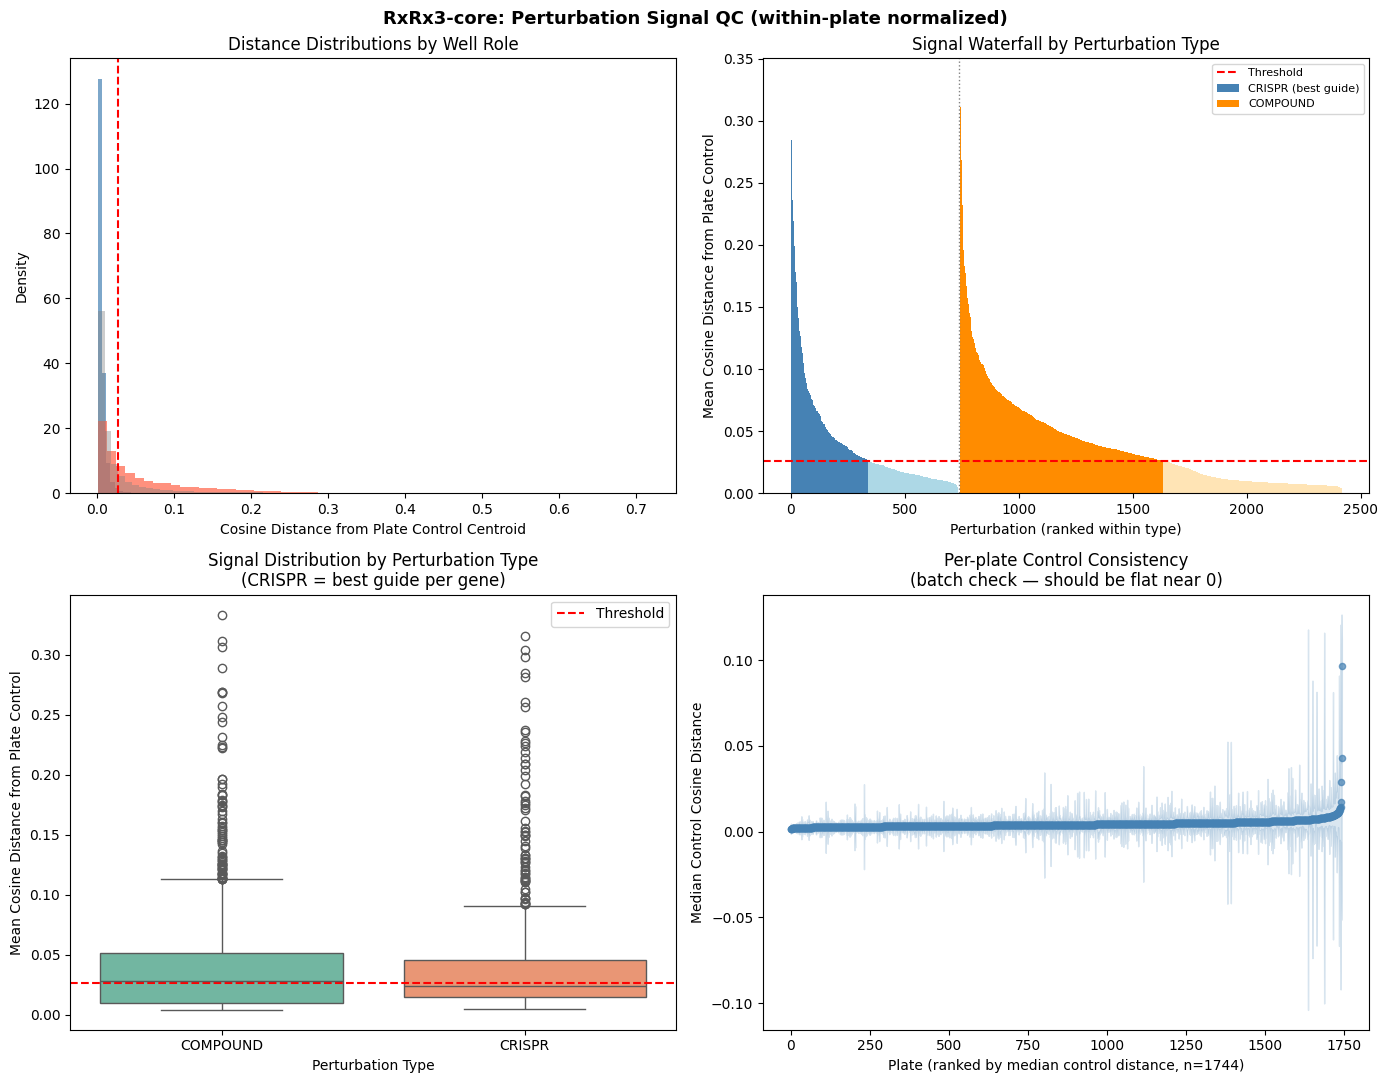


Plot saved to rxrx3_signal_qc_best_guide.png


In [71]:
# 9. Plot visualizations for QC check

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle("RxRx3-core: Perturbation Signal QC (within-plate normalized)", fontsize=13, fontweight="bold")

# --- Plot 1: Distance distributions — neg control, pos control, test perturbations ---
ax = axes[0, 0]
ax.hist(neg_ctrl_dist, bins=60, alpha=0.7, density=True, color='steelblue',  label='Negative control')
ax.hist(pos_ctrl_dist, bins=60, alpha=0.7, density=True, color='tomato',     label='Positive control (PLK1/MTOR)')
ax.hist(test_df['cosine_dist_from_plate_control'], bins=80, alpha=0.4, density=True, color='gray', label='Test perturbations')
ax.axvline(threshold, color='red', linestyle='--', linewidth=1.5, label=f'Threshold ({threshold:.3f})')
ax.set_xlabel('Cosine Distance from Plate Control Centroid')
ax.set_ylabel('Density')
ax.set_title('Distance Distributions by Well Role')

# --- Plot 2: Signal waterfall, colored by perturbation type ---
ax = axes[0, 1]
crispr_rows   = signal_summary[signal_summary['perturbation_type'] == 'CRISPR'].sort_values('mean_dist', ascending=False).reset_index(drop=True)
compound_rows = signal_summary[signal_summary['perturbation_type'] == 'COMPOUND'].sort_values('mean_dist', ascending=False).reset_index(drop=True)

ax.bar(range(len(crispr_rows)),   crispr_rows['mean_dist'],
       color=['steelblue' if a else 'lightblue' for a in crispr_rows['is_active']],
       width=1.0, linewidth=0, label='CRISPR (best guide)')
offset = len(crispr_rows) + 10
ax.bar(range(offset, offset + len(compound_rows)), compound_rows['mean_dist'],
       color=['darkorange' if a else 'moccasin' for a in compound_rows['is_active']],
       width=1.0, linewidth=0, label='COMPOUND')
ax.axhline(threshold, color='red', linestyle='--', linewidth=1.5, label='Threshold')
ax.axvline(len(crispr_rows) + 5, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('Perturbation (ranked within type)')
ax.set_ylabel('Mean Cosine Distance from Plate Control')
ax.set_title('Signal Waterfall by Perturbation Type')
ax.legend(fontsize=8)

# --- Plot 3: CRISPR vs COMPOUND signal boxplot ---
ax = axes[1, 0]
sns.boxplot(data=signal_summary, x='perturbation_type', y='mean_dist', ax=ax, palette='Set2')
ax.axhline(threshold, color='red', linestyle='--', linewidth=1.5, label='Threshold')
ax.set_xlabel('Perturbation Type')
ax.set_ylabel('Mean Cosine Distance from Plate Control')
ax.set_title('Signal Distribution by Perturbation Type\n(CRISPR = best guide per gene)')
ax.legend()

# --- Plot 4: Per-plate control consistency (UNCHANGED) ---
ax = axes[1, 1]
plate_ctrl_stats = (
    df_merge[df_merge['is_negative_control']]
    .groupby('plate_id')['cosine_dist_from_plate_control']
    .agg(['median', 'std', 'count'])
    .sort_values('median')
    .reset_index()
)
ax.scatter(range(len(plate_ctrl_stats)), plate_ctrl_stats['median'],
           s=20, alpha=0.7, color='steelblue')
ax.fill_between(
    range(len(plate_ctrl_stats)),
    plate_ctrl_stats['median'] - plate_ctrl_stats['std'],
    plate_ctrl_stats['median'] + plate_ctrl_stats['std'],
    alpha=0.2, color='steelblue'
)
ax.set_xlabel(f'Plate (ranked by median control distance, n={len(plate_ctrl_stats)})')
ax.set_ylabel('Median Control Cosine Distance')
ax.set_title('Per-plate Control Consistency\n(batch check — should be flat near 0)')

plt.tight_layout()
plt.savefig('rxrx3_signal_qc_best_guide.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nPlot saved to rxrx3_signal_qc_best_guide.png')

In [ ]:
print(signal_summary.head(20))



In [ ]:
max_conc = df_merge['concentration'].max()
high_dose_compounds = df_merge[
    (df_merge['perturbation_type'] == 'COMPOUND') & 
    (df_merge['concentration'] == max_conc)
]['cosine_dist_from_plate_control'].mean()

all_crispr = df_merge[
    df_merge['perturbation_type'] == 'CRISPR'
]['cosine_dist_from_plate_control'].mean()

print(f"Compounds at max dose: {high_dose_compounds:.4f}")
print(f"CRISPR (all): {all_crispr:.4f}")


In [ ]:
for ptype in ['CRISPR', 'COMPOUND']:
    ctrl_dist = df_merge[
        (df_merge['is_negative_control']) & 
        (df_merge['perturbation_type'] == ptype)
    ]['cosine_dist_from_plate_control']
    print(f"{ptype} controls: mean={ctrl_dist.mean():.4f}, std={ctrl_dist.std():.4f}")
    

In [ ]:
print(df_merge.groupby('perturbation_type')[['gene', 'treatment']].apply(lambda x: x.notna().sum()))


In [ ]:
print(df_merge[df_merge['is_positive_control']]['gene'].value_counts())
print(f"Positive controls perturbation_type: {df_merge[df_merge['is_positive_control']]['perturbation_type'].unique()}")

In [ ]:
print(df_merge[df_merge['perturbation_type'] == 'CRISPR']['treatment'].value_counts())


In [ ]:
# Look at guide-level variation for positive controls
plk1_guides = df_merge[df_merge['gene'] == 'PLK1'].groupby('treatment')['cosine_dist_from_plate_control'].agg(['mean', 'count'])
print(plk1_guides.sort_values('mean', ascending=False))

In [ ]:
# For each gene, take only the guide with strongest signal
best_guides = (
    df_merge[df_merge['perturbation_type'] == 'CRISPR']
    .groupby('gene')['cosine_dist_from_plate_control']
    .idxmax()
)
crispr_best_guide = df_merge.loc[best_guides]


In [45]:
# Separate CRISPR and COMPOUND test wells

# Separate CRISPR and COMPOUND test wells
crispr_test = test_df[test_df['perturbation_type'] == 'CRISPR'].copy()
compound_test = test_df[test_df['perturbation_type'] == 'COMPOUND'].copy()

# For each gene, identify which guide (treatment) has the highest mean distance
best_guide_per_gene = (
    crispr_test.groupby('gene')['cosine_dist_from_plate_control']
    .apply(lambda group: 
        crispr_test.loc[group.index].groupby('treatment')['cosine_dist_from_plate_control'].mean().idxmax()
    )
)

print(f"\nBest guide selection:")
print(f"  Example - PLK1 best guide: {best_guide_per_gene.get('PLK1', 'N/A')}")
print(f"  Example - MTOR best guide: {best_guide_per_gene.get('MTOR', 'N/A')}")

# Keep only wells from the best guide for each gene
crispr_best = crispr_test[
    crispr_test.apply(lambda row: row['treatment'] == best_guide_per_gene.get(row['gene']), axis=1)
]

print(f"  Original CRISPR wells: {len(crispr_test):>7,}")
print(f"  After best-guide filter: {len(crispr_best):>7,}")

# Recombine: best CRISPR guides + all compounds
test_df_filtered = pd.concat([crispr_best, compound_test], ignore_index=True)

# ── 8. AGGREGATE BY PERTURBATION (USING FILTERED DATA) ───────────────────────

signal_summary = (
    test_df_filtered.groupby(['perturbation_id', 'perturbation_type'])['cosine_dist_from_plate_control']
    .agg(mean_dist='mean', std_dist='std', n_replicates='count')
    .reset_index()
    .sort_values('mean_dist', ascending=False)
)

signal_summary['is_active'] = signal_summary['mean_dist'] > threshold

n_active = signal_summary['is_active'].sum()
n_total  = len(signal_summary)
print(f"\nActive perturbations (best guide): {n_active} / {n_total} ({100*n_active/n_total:.1f}%)")

print(f"\nTop 15 strongest perturbations:")
print(signal_summary.head(15).to_string(index=False))

print(f"\nBottom 10 weakest perturbations:")
print(signal_summary.tail(10).to_string(index=False))

NameError: name 'test_df' is not defined


Computed mean embeddings for 2407 perturbations

Top 20 compound-gene phenocopies (highest similarity):
                  compound    gene  cosine_similarity
                Pyrilamine  INTS10           0.999411
                      C 87    RARA           0.999410
                      C 87   HACD1           0.999272
Lasmiditan (hydrochloride)    RARA           0.999247
                  Clonixin  INTS10           0.999228
              sulbutiamine  INTS10           0.999224
                  SCIO 469    RARA           0.999218
                Dantrolene   ABCC4           0.999196
                Dantrolene   MED15           0.999195
                Safinamide    RARA           0.999190
   Tirofiban Hydrochloride  INTS10           0.999175
                 Talnetant    RARA           0.999172
                 Obatoclax  CAB39L           0.999171
                    5-BrdU    RARA           0.999168
 Granisetron hydrochloride    RARA           0.999154
               Narlaprevir   AB

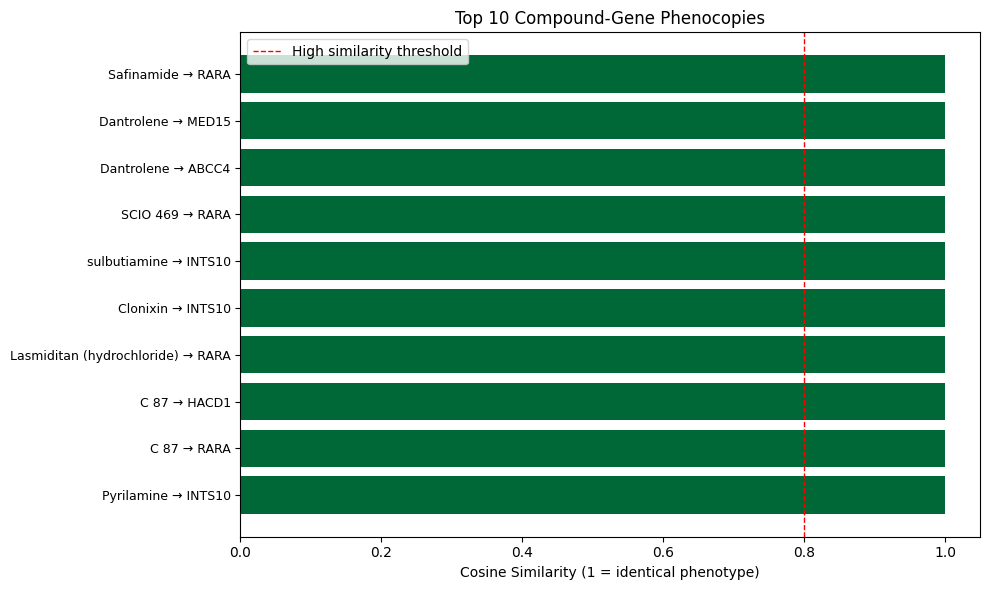

Phenocopy plot saved to rxrx3_top_phenocopies.png


In [72]:


# ── COMPOUND-GENE PHENOCOPY ANALYSIS ──────────────────────────────────────────

from sklearn.metrics.pairwise import cosine_similarity

# Get mean embeddings for each perturbation (best guide for CRISPR)
perturbation_embeddings = {}

# For CRISPR: use only best guides
for gene in best_guide_per_gene.index:
    best_guide = best_guide_per_gene[gene]
    gene_wells = crispr_best[crispr_best['gene'] == gene]
    if len(gene_wells) > 0:
        mean_emb = embeddings[gene_wells.index].mean(axis=0)
        perturbation_embeddings[f"CRISPR_{gene}"] = mean_emb

# For compounds: aggregate across all concentrations (or use max concentration)
for compound in compound_test['treatment'].unique():
    if compound == 'EMPTY_control':
        continue
    compound_wells = compound_test[compound_test['treatment'] == compound]
    if len(compound_wells) > 0:
        mean_emb = embeddings[compound_wells.index].mean(axis=0)
        perturbation_embeddings[f"COMPOUND_{compound}"] = mean_emb

print(f"\nComputed mean embeddings for {len(perturbation_embeddings)} perturbations")

# Convert to matrix for similarity computation
pert_names = list(perturbation_embeddings.keys())
pert_matrix = np.array([perturbation_embeddings[name] for name in pert_names])

# Compute pairwise cosine similarity
similarity_matrix = cosine_similarity(pert_matrix)

# Extract compound-gene pairs only
compound_indices = [i for i, name in enumerate(pert_names) if name.startswith('COMPOUND_')]
gene_indices = [i for i, name in enumerate(pert_names) if name.startswith('CRISPR_')]

# Create a dataframe of compound-gene similarities
phenocopy_results = []

for c_idx in compound_indices:
    compound_name = pert_names[c_idx].replace('COMPOUND_', '')
    for g_idx in gene_indices:
        gene_name = pert_names[g_idx].replace('CRISPR_', '')
        similarity = similarity_matrix[c_idx, g_idx]
        phenocopy_results.append({
            'compound': compound_name,
            'gene': gene_name,
            'cosine_similarity': similarity
        })

phenocopy_df = pd.DataFrame(phenocopy_results).sort_values('cosine_similarity', ascending=False)

print(f"\nTop 20 compound-gene phenocopies (highest similarity):")
print(phenocopy_df.head(20).to_string(index=False))

# Save full results
phenocopy_df.to_csv('rxrx3_compound_gene_phenocopy.csv', index=False)
print(f"\nFull results saved to rxrx3_compound_gene_phenocopy.csv")

# ── VISUALIZE TOP PHENOCOPIES ─────────────────────────────────────────────────

# Show top 10 phenocopies as a heatmap
top_pairs = phenocopy_df.head(10)

fig, ax = plt.subplots(figsize=(10, 6))
y_labels = [f"{row['compound']} → {row['gene']}" for _, row in top_pairs.iterrows()]
colors = plt.cm.RdYlGn(top_pairs['cosine_similarity'].values)

ax.barh(range(len(top_pairs)), top_pairs['cosine_similarity'], color=colors)
ax.set_yticks(range(len(top_pairs)))
ax.set_yticklabels(y_labels, fontsize=9)
ax.set_xlabel('Cosine Similarity (1 = identical phenotype)')
ax.set_title('Top 10 Compound-Gene Phenocopies')
ax.axvline(0.8, color='red', linestyle='--', linewidth=1, label='High similarity threshold')
ax.legend()
plt.tight_layout()
plt.savefig('rxrx3_top_phenocopies.png', dpi=150, bbox_inches='tight')
plt.show()
print("Phenocopy plot saved to rxrx3_top_phenocopies.png")
